In [10]:
!pip install roboflow supervision flash-attn --upgrade -q
!pip install -r requirements.txt
!pip install -e .
!pip install --upgrade flash-attn

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [19 lines of output]
      /tmp/pip-install-wls54uob/flash-attn_f0e8fa1476c4459280fcc79c2475e942/setup.py:106: UserWarning: flash_attn was requested, but nvcc was not found.  Are you sure your environment has nvcc available?  If you're installing within a container from https://hub.docker.com/r/pytorch/pytorch, only images whose names contain 'devel' will provide nvcc.
        warnings.warn(
      Traceback (most recent call last):
        File "<string>", line 2, in <module>
        File "<pip-setuptools-caller>", line 34, in <module>
        File "/tmp/pip-install-wls54uob/flash-attn_f0e8fa1476c4459280fcc79c2475e942/setup.py", line 198, in <module>
          CUDAExtension(
        File "/usr/local/lib/python3.10/site-packages/torch/utils/cpp_extension.py", line 1078, in CUDAExtension
          library_dirs += library_paths(cuda=True)
        File "/usr/local/lib/pyth

In [ ]:
!pip install supervision

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!nvidia-smi

Wed Mar  5 19:48:51 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       1MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [46]:
HOME = os.getcwd()
print(HOME)
datasetPath = "/kaggle/input/weapon-dataset-for-yolov5"
print(os.listdir(dataset))


/kaggle/working/yolov12
['dataset.yaml', 'dataset']


In [16]:
import cv2
from roboflow import Roboflow
import torch
import matplotlib.pyplot as plt
from matplotlib import animation, rc
rc('animation', html='jshtml')
import supervision as sv
from tqdm import tqdm
import shutil
from shutil import copyfile
import random
from PIL import Image
import torchvision.transforms as transforms

In [64]:

rf = Roboflow(api_key="dbMtrWScZeNsFKtPotBm")
project = rf.workspace("weapondetection-um7tj").project("gun-and-knife-detection-system")
version = project.version(13)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Gun-and-Knife-Detection-System-13 in yolov11:: 100%|██████████| 4816/4816 [00:00<00:00, 7259.97it/s]


In [31]:
from ultralytics import YOLO
import shutil
from shutil import copyfile

In [65]:
from ultralytics import YOLO

model = YOLO("yolo12n.pt")

!yolo task=detect mode=train model=yolo12n.pt data="/kaggle/working/yolov12/yolov12/Gun-and-Knife-Detection-System-13/data.yaml" epochs=250

100%|██████████| 5.34M/5.34M [00:00<00:00, 96.9MB/s]


FlashAttention is not available on this device. Using scaled_dot_product_attention instead.
New https://pypi.org/project/ultralytics/8.3.84 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo12n.pt, data=/kaggle/working/yolov12/yolov12/Gun-and-Knife-Detection-System-13/data.yaml, epochs=250, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train6, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, 

7
['/kaggle/working/yolov12/runs/detect/train6/F1_curve.png', '/kaggle/working/yolov12/runs/detect/train6/PR_curve.png', '/kaggle/working/yolov12/runs/detect/train6/P_curve.png']


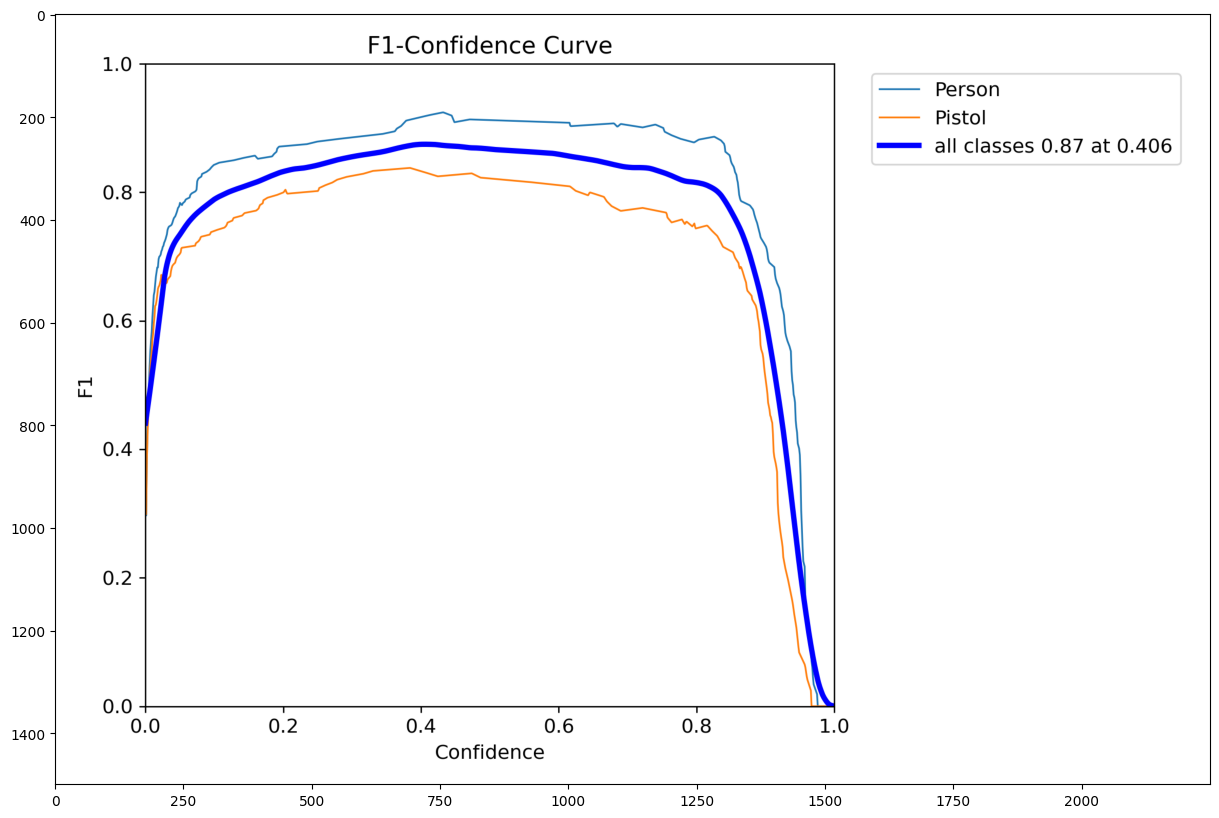

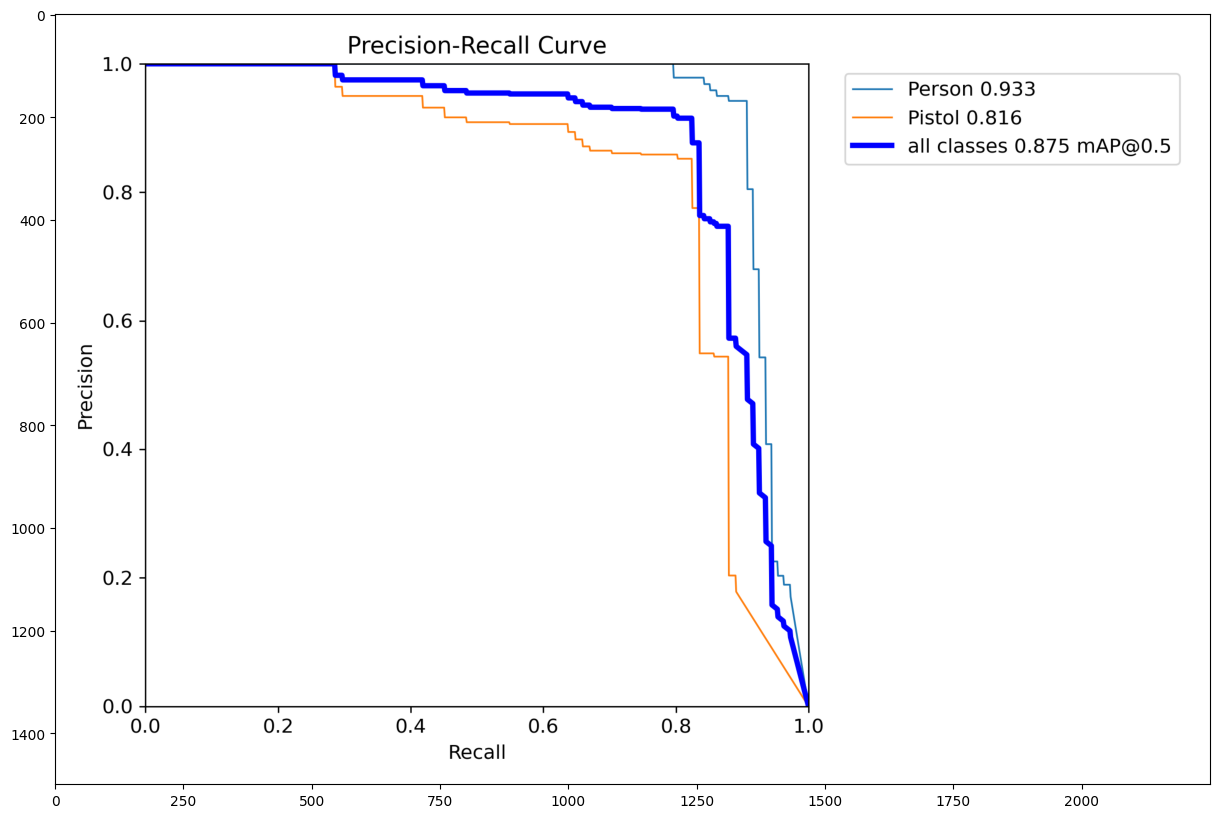

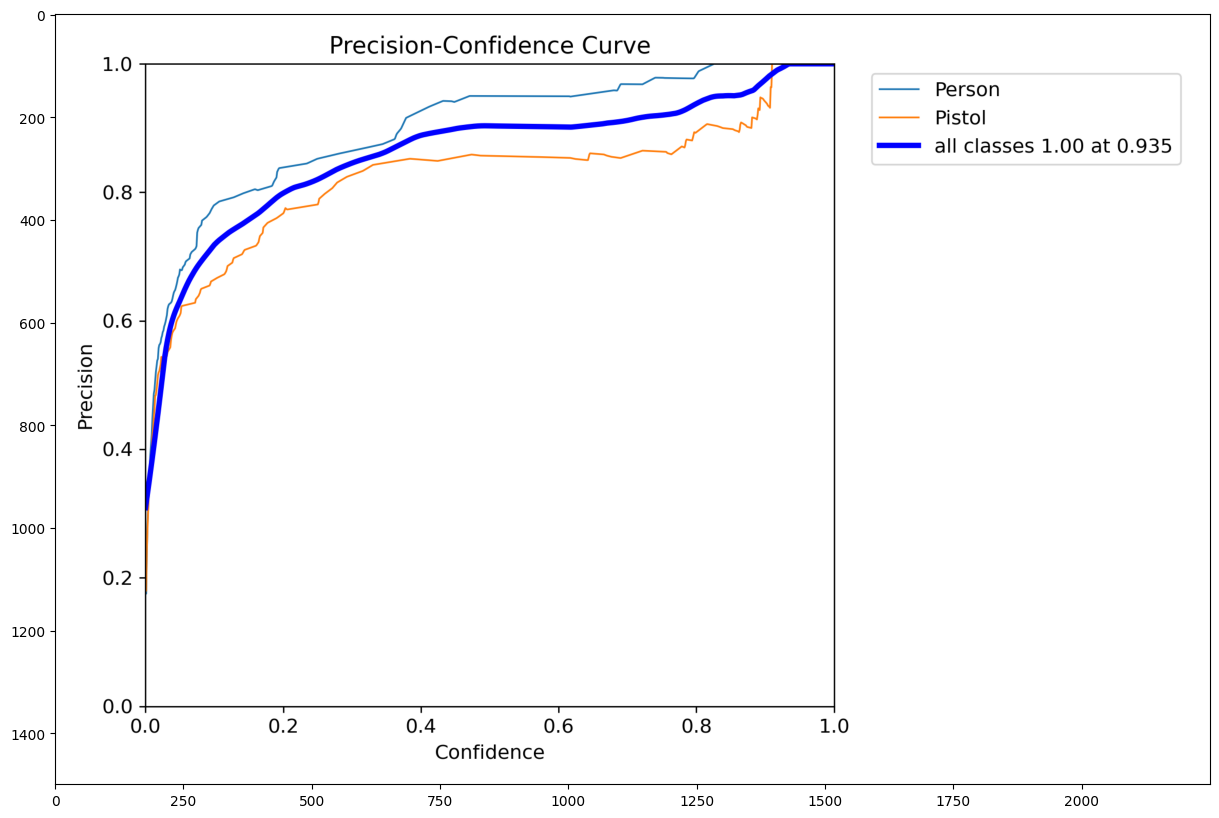

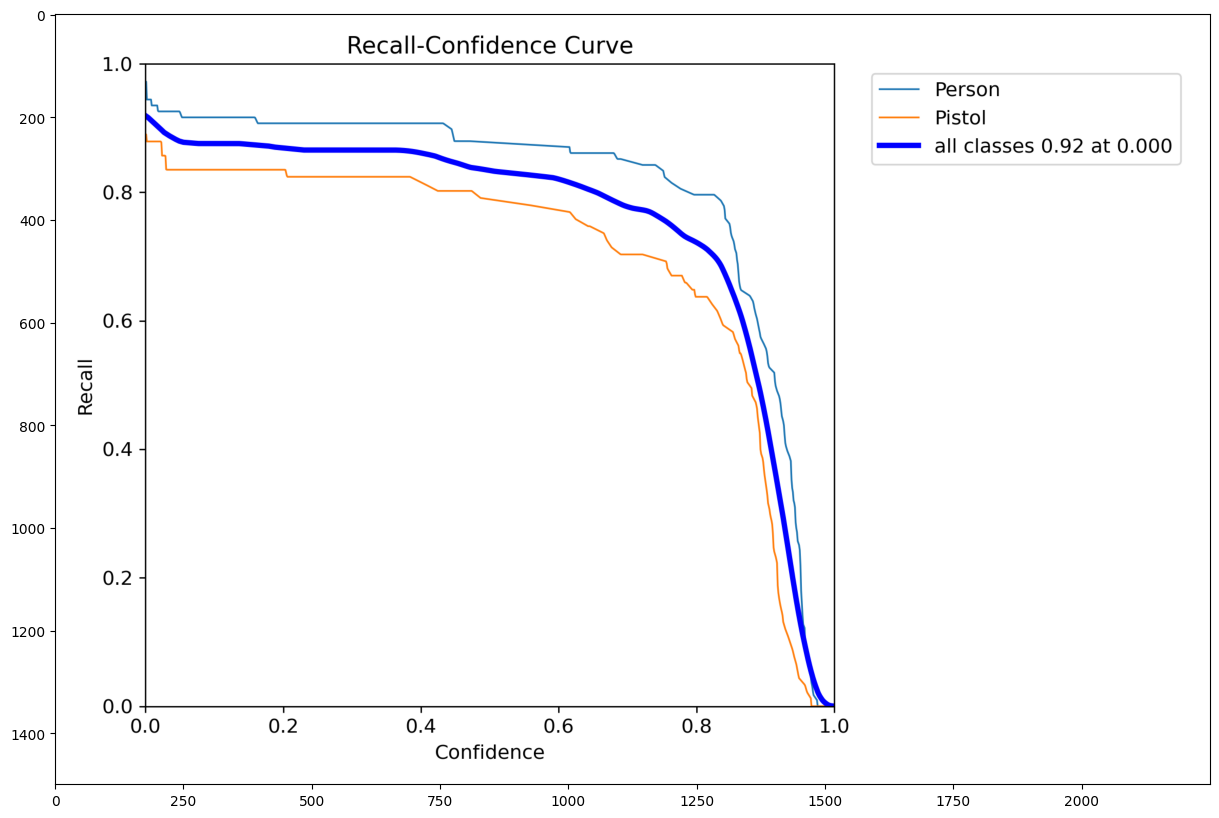

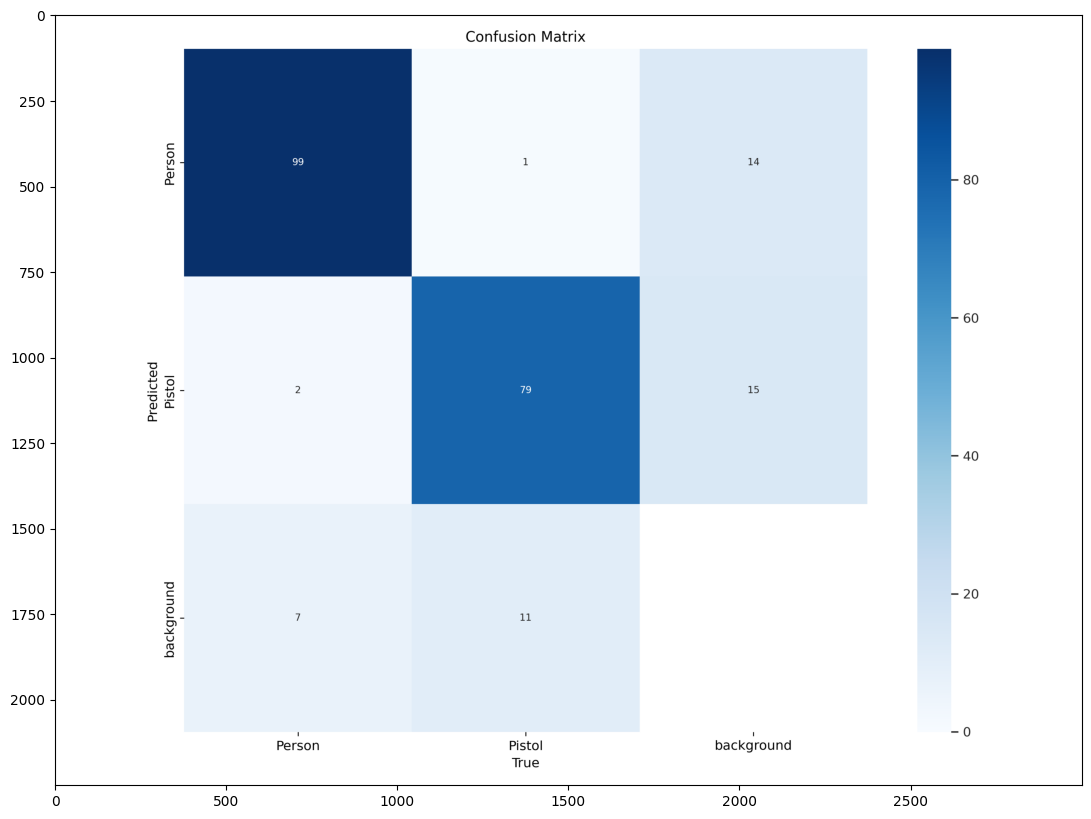

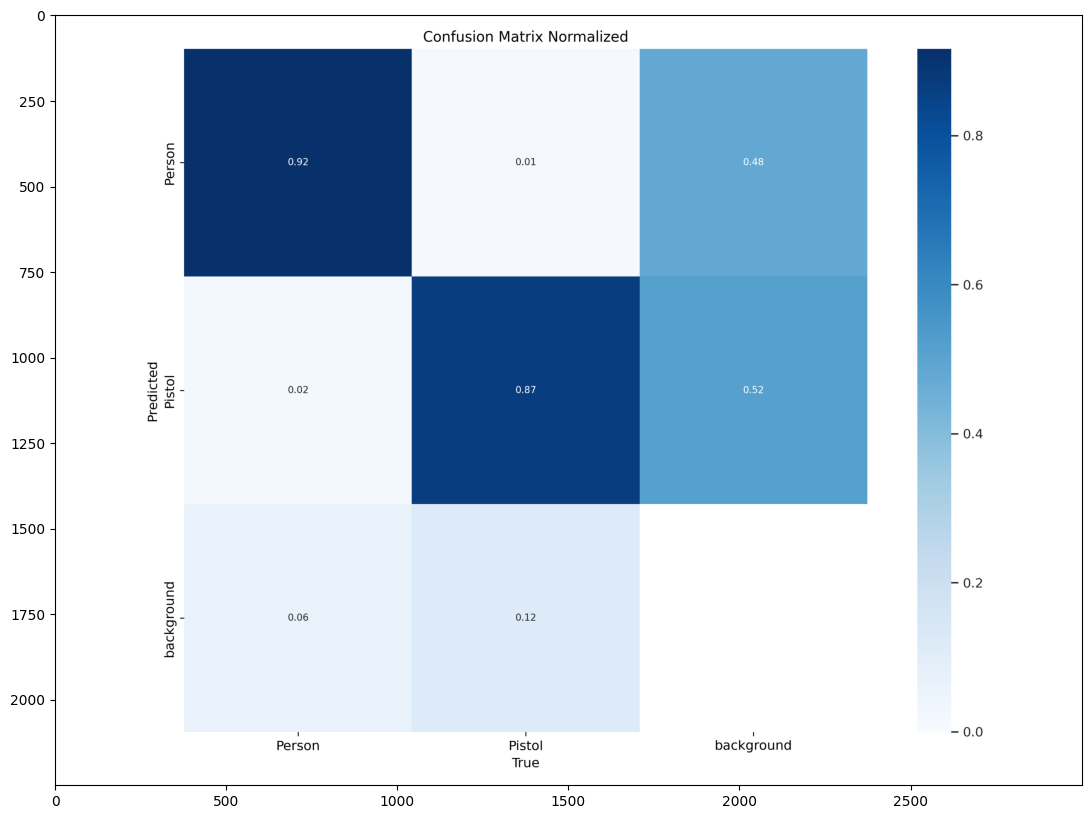

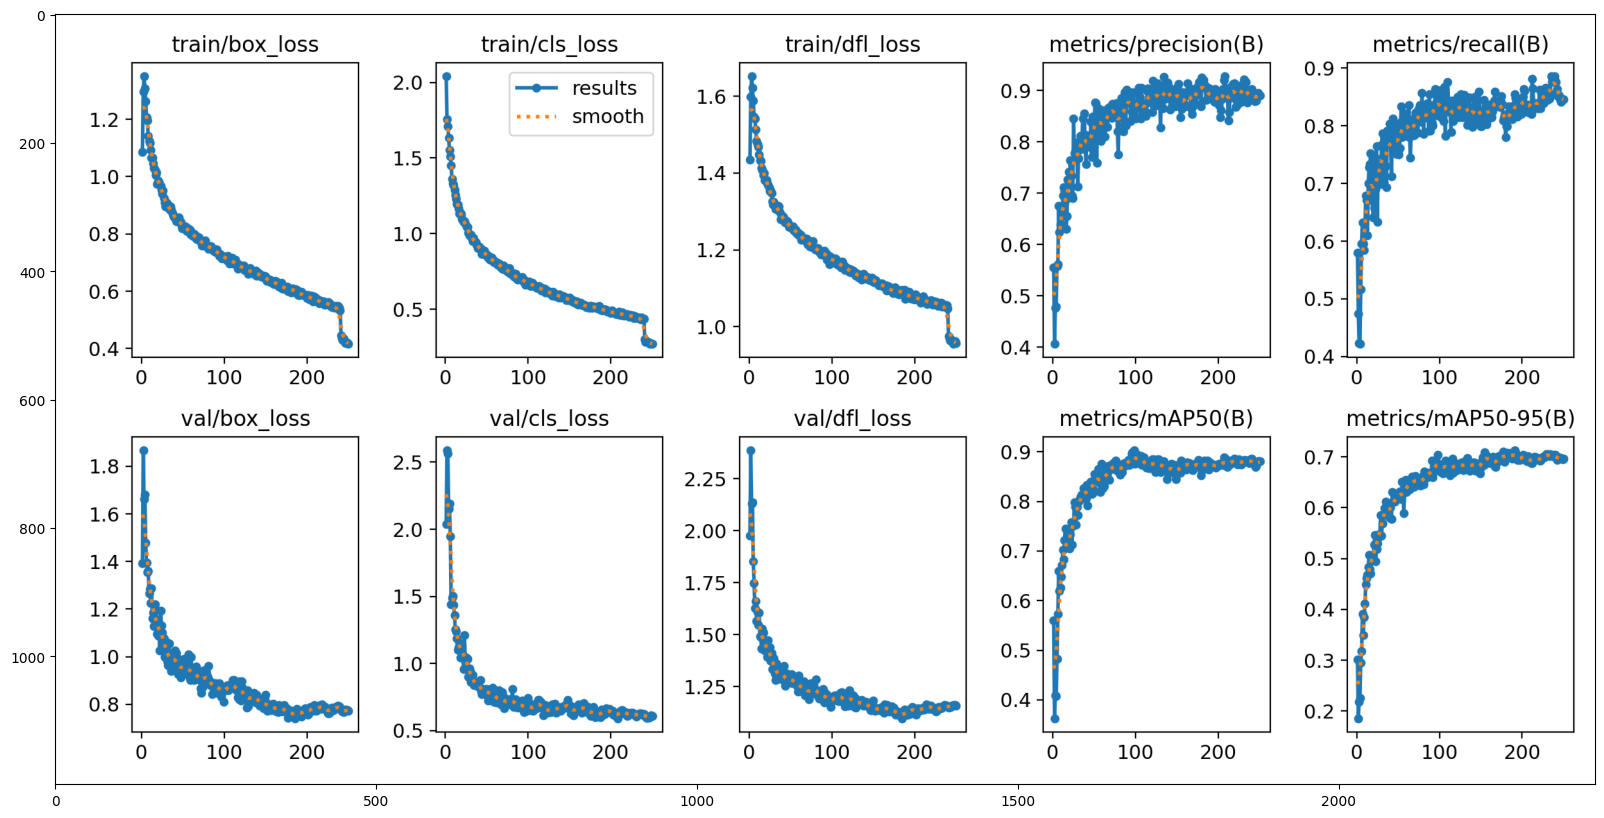

In [74]:
paths2=[]
for dirname, _, filenames in os.walk('/kaggle/working/yolov12/runs/detect/train6'):
    for filename in filenames:
        if filename[-4:]=='.png' or filename[-4:]=='.jpeg':
            paths2+=[(os.path.join(dirname, filename))]
paths2=sorted(paths2)
print(len(paths2))
print(paths2[0:3])

for path in paths2:
    image = Image.open(path)
    image=np.array(image)
    plt.figure(figsize=(20,10))
    plt.imshow(image)
    plt.show()
    

In [124]:
valid_path = '/kaggle/working/yolov12/yolov12/Gun-and-Knife-Detection-System-13/test'
best_path0='/kaggle/working/yolov12/runs/detect/train6/weights/best.pt'
source0=os.path.join(valid_path,'images')

ppaths=[]
for dirname, _, filenames in os.walk(source0):
    for filename in filenames:
        ppaths+=[(os.path.join(dirname, filename))]
ppaths=sorted(ppaths)
print(len(ppaths))

model2 = YOLO(best_path0)
!yolo task=detect mode=predict model={best_path0} conf=0.6 source={source0}


2
FlashAttention is not available on this device. Using scaled_dot_product_attention instead.
Ultralytics 8.3.63 🚀 Python-3.10.16 torch-2.5.0+cu124 CPU (Intel Xeon 2.00GHz)
YOLOv12n summary (fused): 352 layers, 2,557,118 parameters, 0 gradients, 6.3 GFLOPs

image 1/2 /kaggle/working/yolov12/yolov12/Gun-and-Knife-Detection-System-13/test/images/5Days_Daniil_Beretta_3_jpg.rf.7e0011377b4c8ee755ef919154763a58.jpg: 640x640 2 Persons, 1 Pistol, 125.0ms
image 2/2 /kaggle/working/yolov12/yolov12/Gun-and-Knife-Detection-System-13/test/images/ss_weapon-141-_jpg.rf.acf0d55b3bf466c70cca79883527a8ee.jpg: 640x640 1 Person, 1 Pistol, 104.9ms
Speed: 2.4ms preprocess, 115.0ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/yolov12/runs/detect/predict4
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [125]:
results = model2.predict(source0,conf=0.6)



image 1/2 /kaggle/working/yolov12/yolov12/Gun-and-Knife-Detection-System-13/test/images/5Days_Daniil_Beretta_3_jpg.rf.7e0011377b4c8ee755ef919154763a58.jpg: 640x640 2 Persons, 1 Pistol, 95.3ms
image 2/2 /kaggle/working/yolov12/yolov12/Gun-and-Knife-Detection-System-13/test/images/ss_weapon-141-_jpg.rf.acf0d55b3bf466c70cca79883527a8ee.jpg: 640x640 1 Person, 1 Pistol, 75.4ms
Speed: 2.6ms preprocess, 85.3ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


In [126]:
print(len(results))
print(len(ppaths))

2
2


In [127]:
PBOX=pd.DataFrame(columns=range(6))
for i in range(len(results)):
    arri=pd.DataFrame(results[i].boxes.data.cpu().numpy()).astype(float)
    path=ppaths[i]
    file=path.split('/')[-1]
    arri=arri.assign(file=file)
    arri=arri.assign(i=i)
    PBOX=pd.concat([PBOX,arri],axis=0)
PBOX.columns=['x','y','x2','y2','confidence','class','file','i']
display(PBOX)

,x,y,x2,y2,confidence,class,file,i
0,43.375946,103.839111,372.097809,639.877380,0.947569,0.0,5Days_Daniil_Beretta_3_jpg.rf.7e0011377b4c8ee7...,0.0
1,327.652588,139.332611,425.349487,345.552002,0.906400,1.0,5Days_Daniil_Beretta_3_jpg.rf.7e0011377b4c8ee7...,0.0
2,354.211426,1.871216,602.101074,639.301270,0.843121,0.0,5Days_Daniil_Beretta_3_jpg.rf.7e0011377b4c8ee7...,0.0
0,32.880859,17.235474,381.049316,640.000000,0.945200,0.0,ss_weapon-141-_jpg.rf.acf0d55b3bf466c70cca7988...,1.0
1,259.188171,277.099670,378.519592,421.875549,0.754981,1.0,ss_weapon-141-_jpg.rf.acf0d55b3bf466c70cca7988...,1.0


In [128]:
Name = ['Person', 'Pistol']
N = list(range(2))
normal_mapping = dict(zip(Name, N))  # {'Person': 0, 'Pistol': 1}
reverse_mapping = dict(zip(N, Name))  # {0: 'Person', 1: 'Pistol'}

# Define color mappings
cmapping = {
    0: (255, 0, 0),  # Red for class 0 (Person)
    1: (0, 255, 0),  # Green for class 1 (Pistol)
}


In [129]:
def draw_boxes(image, boxes):
    for _, row in boxes.iterrows():
        x1, y1, x2, y2 = int(row['x']), int(row['y']), int(row['x2']), int(row['y2'])
        confidence = row['confidence']
        class_id = int(row['class'])
        
        # Map class ID to class name and color
        class_name = reverse_mapping[class_id]
        color = cmapping[class_id]
        
        # Draw bounding box
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
        
        # Draw label (class name and confidence)
        label = f'{class_name} {confidence:.2f}'
        cv2.putText(image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)
    
    return image

# Function to process all images
def process_images(ppaths, PBOX):
    processed_images = []
    for i, path in enumerate(tqdm(ppaths)):
        # Load the image
        image = cv2.imread(path)
        if image is None:
            print(f"Warning: Unable to load image at {path}")
            continue
        
        # Get bounding boxes for this image
        boxes = PBOX[PBOX['i'] == i]
        
        # Draw bounding boxes on the image
        image_with_boxes = draw_boxes(image, boxes)
        processed_images.append(image_with_boxes)
    
    return processed_images

# Example usage
# Assuming `ppaths` is your list of image paths and `PBOX` is your DataFrame
processed_images = process_images(ppaths, PBOX)


100%|██████████| 2/2 [00:00<00:00, 264.29it/s]


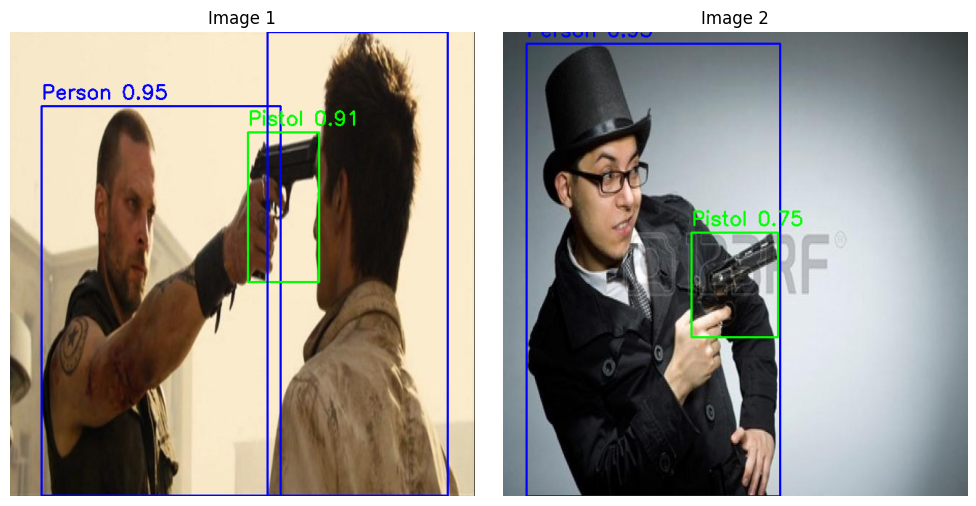

In [130]:
# Display only 2 processed images
def display_images(images, num_images=2):
    images = images[:num_images]  # Slice the first 2 images
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns
    axes = axes.ravel()
    
    for i, img in enumerate(images):
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
        axes[i].imshow(img_rgb)
        axes[i].set_title(f'Image {i+1}')
        axes[i].axis('off')  # Hide axes
    
    plt.tight_layout()
    plt.show()

# Display the first 2 images with bounding boxes
display_images(processed_images)